# **Exploración de los datos**

Realiza un análisis exploratorio del conjunto de datos que incluya:

    • Dimensiones del dataset.
    • Tipos de variables.
    • Valores nulos.
    • Registros duplicados.
    • Estadísticos descriptivos.
    • Visualizaciones que permitan comprender la información.


In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

#Visualizacion
import seaborn as sns
import matplotlib.pyplot as plt

#1. Carga de Datasets (Para pruebas)
from sklearn.datasets import load_iris
# 2. Preparación y Preprocesamiento de datos
from sklearn.preprocessing import StandardScaler

# 3. Reducción de Dimensionalidad (Para visualización o modelado)

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Evaluación y Métricas
from sklearn import metrics

In [6]:
# Asignamos nombres explicativos a las columnas
col_names = ['user_id', 'game', 'behavior', 'hours', 'flag']

# Leemos el archivo indicando que no tiene encabezado
df = pd.read_csv('steam-200k.csv', header=None, names=col_names)

# Eliminamos la última columna (flag de ceros)
df = df.drop(columns=['flag'])

# Mostramos las primeras filas
df.head(10)

,user_id,game,behavior,hours
0,151603712,The Elder Scrolls V Skyrim,purchase,1.0
1,151603712,The Elder Scrolls V Skyrim,play,273.0
2,151603712,Fallout 4,purchase,1.0
3,151603712,Fallout 4,play,87.0
4,151603712,Spore,purchase,1.0
5,151603712,Spore,play,14.9
6,151603712,Fallout New Vegas,purchase,1.0
7,151603712,Fallout New Vegas,play,12.1
8,151603712,Left 4 Dead 2,purchase,1.0
9,151603712,Left 4 Dead 2,play,8.9


In [7]:
# Dimensiones del data
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

Número de filas: 200000
Número de columnas: 4


In [8]:
#resumen general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   user_id   200000 non-null  int64  
 1   game      200000 non-null  object 
 2   behavior  200000 non-null  object 
 3   hours     200000 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 6.1+ MB


In [9]:
# Suma de valores nulos por cada columna
df.isnull().sum()

,0
user_id,0
game,0
behavior,0
hours,0


In [10]:
# Conteo de filas exactamente iguales
print(f"Registros duplicados: {df.duplicated().sum()}")

Registros duplicados: 707


In [13]:
# Estadísticos para la variable numérica (horas)
print("=== Variables Numéricas ===")
display(df.describe())

# Estadísticos para variables categóricas (juegos, comportamiento, usuarios)
print("\n== Variables Categóricas ===")
display(df.describe(include=['object']))

=== Variables Numéricas ===


,user_id,hours
count,2.000000e+05,200000.000000
mean,1.036559e+08,17.874384
std,7.208074e+07,138.056952
min,5.250000e+03,0.100000
25%,4.738420e+07,1.000000
50%,8.691201e+07,1.000000
75%,1.542309e+08,1.300000
max,3.099031e+08,11754.000000



== Variables Categóricas ===


,game,behavior
count,200000,200000
unique,5155,2
top,Dota 2,purchase
freq,9682,129511


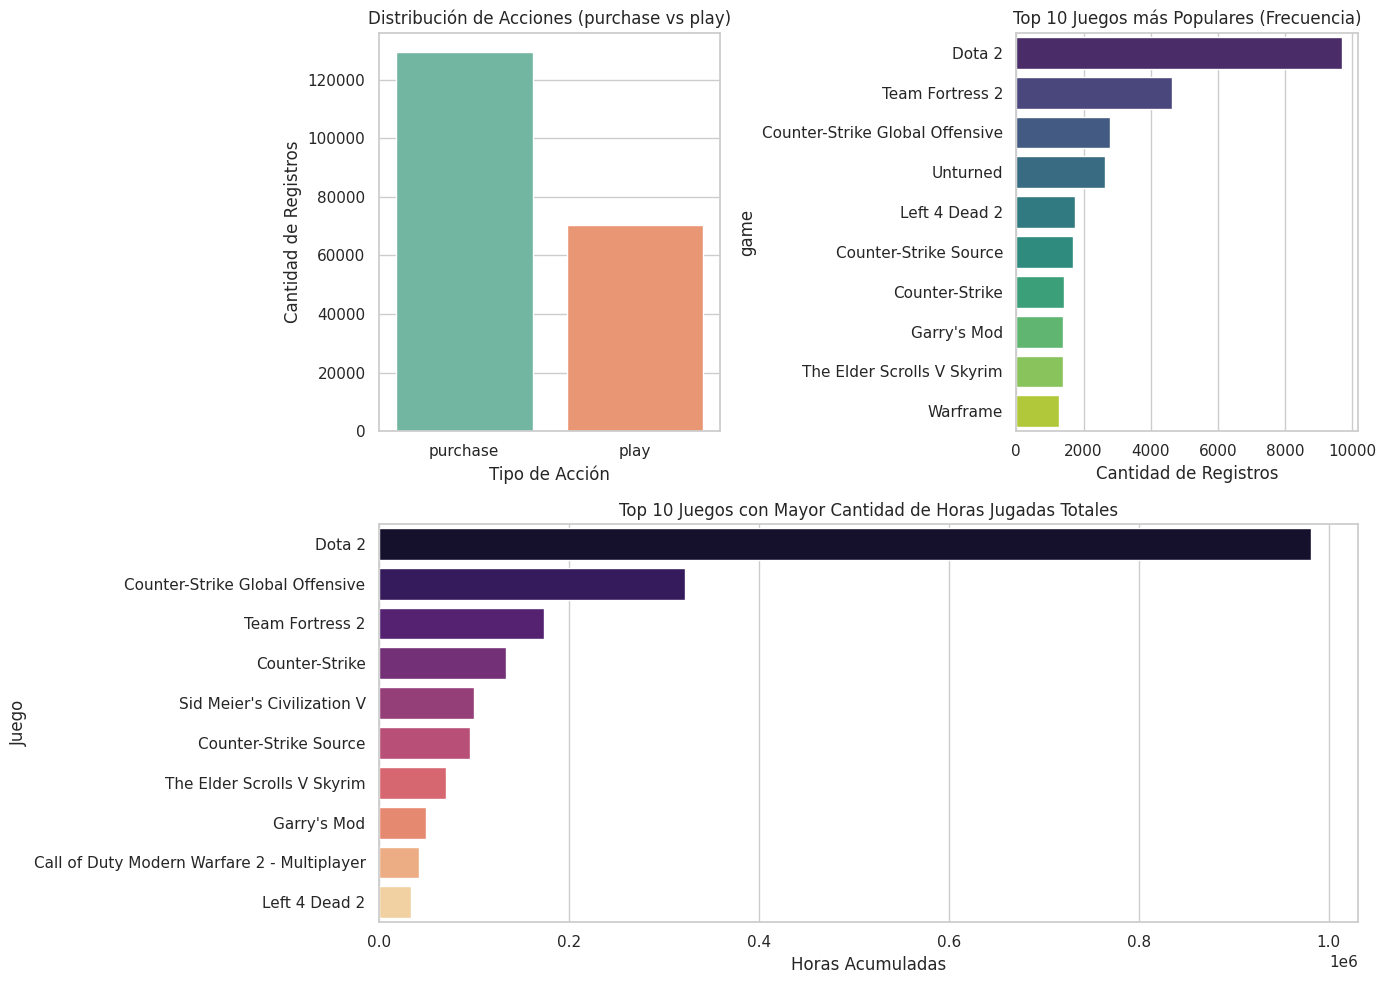

In [15]:
# Ajustes de estilo general
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 10))

# Visualización 1: Distribución entre Compra y Juego
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='behavior', hue='behavior', palette='Set2', legend=False)
plt.title('Distribución de Acciones (purchase vs play)')
plt.xlabel('Tipo de Acción')
plt.ylabel('Cantidad de Registros')

# Visualización 2: Top 10 juegos más frecuentes en la plataforma
plt.subplot(2, 2, 2)
top_games = df['game'].value_counts().head(10)
sns.barplot(x=top_games.values, y=top_games.index, hue=top_games.index, palette='viridis', legend=False)
plt.title('Top 10 Juegos más Populares (Frecuencia)')
plt.xlabel('Cantidad de Registros')

# Visualización 3: Top 10 juegos con más horas jugadas acumuladas
plt.subplot(2, 2, (3, 4))
df_play = df[df['behavior'] == 'play']
top_hours = df_play.groupby('game')['hours'].sum().nlargest(10)
sns.barplot(x=top_hours.values, y=top_hours.index, hue=top_hours.index, palette='magma', legend=False)
plt.title('Top 10 Juegos con Mayor Cantidad de Horas Jugadas Totales')
plt.xlabel('Horas Acumuladas')
plt.ylabel('Juego')

plt.tight_layout()
plt.show()

# **Preparación de los datos**

Realiza el preprocesamiento necesario para aplicar técnicas de clustering.

Debes justificar cada decisión tomada.

Por ejemplo:

    • Eliminación de variables irrelevantes.
    • Transformación del dataset para obtener variables por usuario.
    • Ingeniería de características (si aplica).
    • Escalamiento de variables.
    Importante: El dataset original se encuentra en formato de interacciones usuario–videojuego. Será necesario transformarlo para construir variables representativas de cada usuario antes de realizar el clustering.


In [17]:
df_copia = df.copy()

In [19]:
# ==============================================================================
# 1. ELIMINACIÓN DE VARIABLES IRRELEVANTES Y FILTRADO INICIAL
# ==============================================================================
# La variable 'flag' (columna de ceros) y los títulos específicos ('game')
# no aportan métricas numéricas agregadas por usuario para clustering.
# Para contabilizar correctamente las horas, filtramos los registros de uso ('play').

# ==============================================================================
# 2. TRANSFORMACIÓN A NIVEL DE USUARIO E INGENIERÍA DE CARACTERÍSTICAS
# ==============================================================================
# Transformamos el dataset agrupando por usuario (user_id)
df_user = df_copia.groupby('user_id').agg(
    total_compras=('behavior', lambda x: (x == 'purchase').sum()),
    total_juegos_jugados=('behavior', lambda x: (x == 'play').sum()),
    total_horas=('hours', lambda x: x[df_copia.loc[x.index, 'behavior'] == 'play'].sum())
).reset_index()

# Creación de variables derivadas (Feature Engineering):
# a) Horas promedio dedicadas a los juegos que realmente juega
df_user['horas_promedio_por_juego'] = (
    df_user['total_horas'] / df_user['total_juegos_jugados']
).fillna(0)

# b) Ratio de conversión (proporción de la biblioteca comprada que ha sido jugada)
df_user['ratio_juegos_jugados'] = (
    df_user['total_juegos_jugados'] / df_user['total_compras']
).fillna(0)

# Guardamos una copia limpia de los datos agregados antes de escalar
df_user_raw = df_user.copy()

# ==============================================================================
# 3. SELECCIÓN DE MATRIZ Y ESCALAMIENTO DE VARIABLES
# ==============================================================================
# Eliminamos el identificador de usuario (user_id) ya que no es una variable cuantitativa
X_user = df_user.drop(columns=['user_id'])

# Aplicamos StandardScaler para estandarizar las variables (media=0, desv.est.=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_user)

# Convertimos a DataFrame escalado
X_scaled_df = pd.DataFrame(X_scaled, columns=X_user.columns)

print("Preprocesamiento y escalamiento completados.")
print(f"Dimensiones finales de la matriz para clustering: {X_scaled_df.shape}")
X_scaled_df.head()

Preprocesamiento y escalamiento completados.
Dimensiones finales de la matriz para clustering: (12393, 5)


,total_compras,total_juegos_jugados,total_horas,horas_promedio_por_juego,ratio_juegos_jugados
0,0.294167,0.018277,-0.069069,-0.129478,-1.276015
1,0.712428,0.837879,1.248278,-0.045716,-0.493744
2,1.995093,0.545164,-0.030265,-0.202022,-1.573997
3,-0.012557,-0.332982,-0.365686,-0.261936,-2.104302
4,-0.068325,-0.274439,-0.365554,-0.261584,-1.741927


# **Modelado**

Implementa un algoritmo de clustering, por ejemplo:

    • K-Means
    • DBSCAN
    • Clustering Jerárquico
Justifica la elección del algoritmo utilizados.

JUSTIFICACIÓN DE LA ELECCIÓN DEL ALGORITMO: K-MEANS
1. Eficiencia: Computacionalmente rápido y escalable para miles de registros.
2. Interpretación: Los centroides representan directamente el comportamiento promedio del usuario.
3. Compatibilidad: Funciona óptimamente con variables numéricas estandarizadas (StandardScaler).



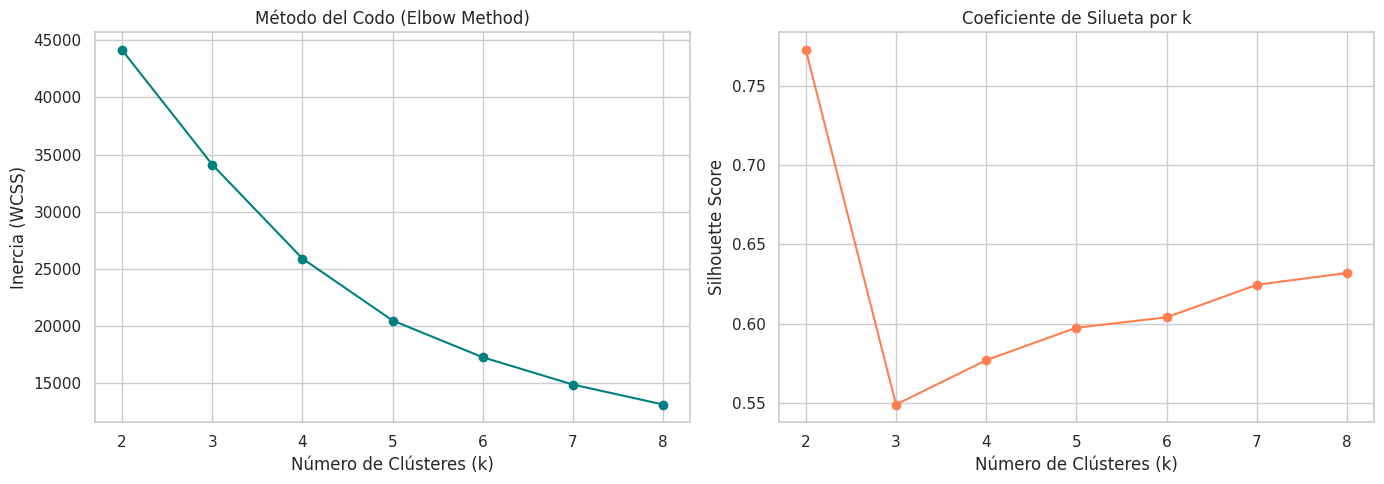


RESULTADO DE LA ASIGNACIÓN (k = 3)
Coeficiente de Silueta logrado: 0.5490
Explicación de k:
- k = 2 otorga la mayor separación matemática (Silueta max).
- k = 3 ofrece una mejor interpretabilidad de negocio para segmentar perfiles de usuarios.


In [22]:
# ==============================================================================
# EXPLICACIÓN Y JUSTIFICACIÓN DEL ALGORITMO
# ==============================================================================
print("=" * 70)
print("JUSTIFICACIÓN DE LA ELECCIÓN DEL ALGORITMO: K-MEANS")
print("=" * 70)
print("1. Eficiencia: Computacionalmente rápido y escalable para miles de registros.")
print("2. Interpretación: Los centroides representan directamente el comportamiento promedio del usuario.")
print("3. Compatibilidad: Funciona óptimamente con variables numéricas estandarizadas (StandardScaler).")
print("=" * 70 + "\n")

# ==============================================================================
# 1. EVALUACIÓN DEL NÚMERO ÓPTIMO DE CLÚSTERES (K)
# ==============================================================================
inertia = []
silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(X_scaled_df)
    inertia.append(kmeans_test.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled_df, kmeans_test.labels_))

# Visualización corregida (sin avisos de formato redundante)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico del Codo
ax[0].plot(K_range, inertia, 'o-', color='teal')
ax[0].set_title('Método del Codo (Elbow Method)')
ax[0].set_xlabel('Número de Clústeres (k)')
ax[0].set_ylabel('Inercia (WCSS)')

# Gráfico de Silueta
ax[1].plot(K_range, silhouette_scores, 'o-', color='coral')
ax[1].set_title('Coeficiente de Silueta por k')
ax[1].set_xlabel('Número de Clústeres (k)')
ax[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

# ==============================================================================
# 2. SELECCIÓN DE K Y ASIGNACIÓN DE CLÚSTERES
# ==============================================================================
# Nota: Evaluamos k=2 (mayor Silueta ~0.77) frente a k=3 (equilibrio Codo/Silueta)
k_seleccionado = 3

kmeans_final = KMeans(n_clusters=k_seleccionado, random_state=42, n_init=10)
df_user['cluster'] = kmeans_final.fit_predict(X_scaled_df)

score_final = silhouette_score(X_scaled_df, df_user['cluster'])

print("\n" + "=" * 70)
print(f"RESULTADO DE LA ASIGNACIÓN (k = {k_seleccionado})")
print("=" * 70)
print(f"Coeficiente de Silueta logrado: {score_final:.4f}")
print("Explicación de k:")
print("- k = 2 otorga la mayor separación matemática (Silueta max).")
print(f"- k = {k_seleccionado} ofrece una mejor interpretabilidad de negocio para segmentar perfiles de usuarios.")
print("=" * 70)

# **Interpretación de los clusters**

Describe cada uno de los grupos encontrados.
Puedes responder preguntas como:

    • Qué caracteriza a los usuarios de este grupo?
    • Son jugadores ocasionales o frecuentes?
    • Presentan comportamientos similares de compra?
    • Qué diferencias existen entre los clusters?

Asigna un nombre representativo a cada segmento.
Ejemplo:

    • Jugadores Casual
    • Coleccionistas
    • Usuarios Muy Activos
    • Compradores Frecuentes


JUSTIFICACIÓN DE LA ELECCIÓN DEL ALGORITMO: K-MEANS
1. Eficiencia: Computacionalmente rápido y escalable para miles de registros.
2. Interpretación: Los centroides representan directamente el comportamiento promedio del usuario.
3. Compatibilidad: Funciona óptimamente con variables numéricas estandarizadas (StandardScaler).



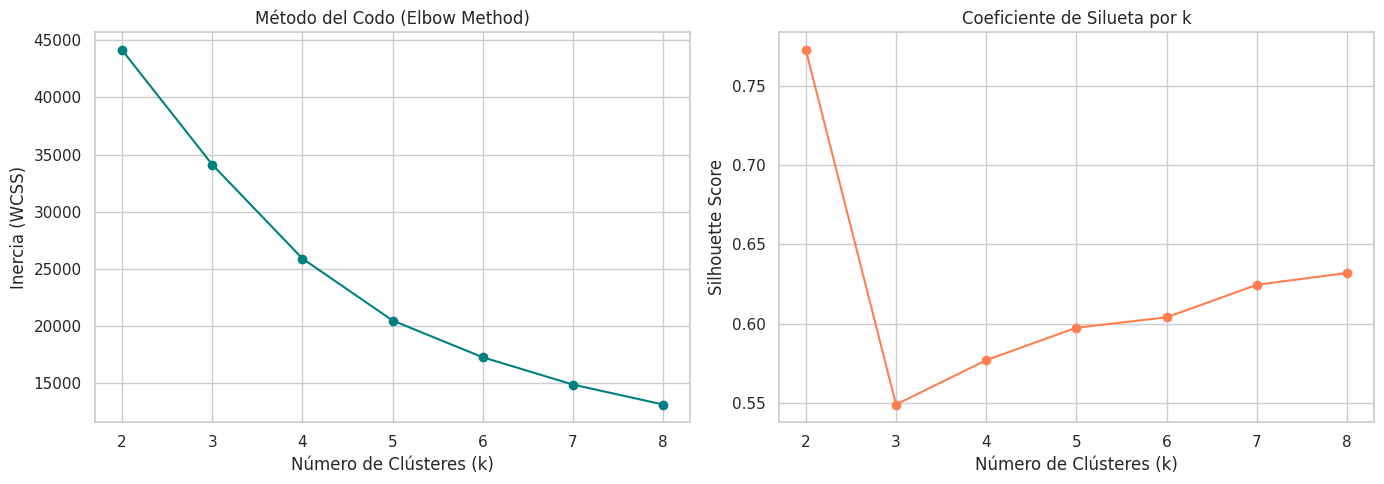


RESULTADO DE LA ASIGNACIÓN (k = 3)
Coeficiente de Silueta logrado: 0.5490
Explicación de k:
- k = 2 otorga la mayor separación matemática (Silueta max).
- k = 3 ofrece una mejor interpretabilidad de negocio para segmentar perfiles de usuarios.


In [23]:
# ==============================================================================
# EXPLICACIÓN Y JUSTIFICACIÓN DEL ALGORITMO
# ==============================================================================
print("=" * 70)
print("JUSTIFICACIÓN DE LA ELECCIÓN DEL ALGORITMO: K-MEANS")
print("=" * 70)
print("1. Eficiencia: Computacionalmente rápido y escalable para miles de registros.")
print("2. Interpretación: Los centroides representan directamente el comportamiento promedio del usuario.")
print("3. Compatibilidad: Funciona óptimamente con variables numéricas estandarizadas (StandardScaler).")
print("=" * 70 + "\n")

# ==============================================================================
# 1. EVALUACIÓN DEL NÚMERO ÓPTIMO DE CLÚSTERES (K)
# ==============================================================================
inertia = []
silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(X_scaled_df)
    inertia.append(kmeans_test.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled_df, kmeans_test.labels_))

# Visualización corregida (sin avisos de formato redundante)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico del Codo
ax[0].plot(K_range, inertia, 'o-', color='teal')
ax[0].set_title('Método del Codo (Elbow Method)')
ax[0].set_xlabel('Número de Clústeres (k)')
ax[0].set_ylabel('Inercia (WCSS)')

# Gráfico de Silueta
ax[1].plot(K_range, silhouette_scores, 'o-', color='coral')
ax[1].set_title('Coeficiente de Silueta por k')
ax[1].set_xlabel('Número de Clústeres (k)')
ax[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

# ==============================================================================
# 2. SELECCIÓN DE K Y ASIGNACIÓN DE CLÚSTERES
# ==============================================================================
# Nota: Evaluamos k=2 (mayor Silueta ~0.77) frente a k=3 (equilibrio Codo/Silueta)
k_seleccionado = 3

kmeans_final = KMeans(n_clusters=k_seleccionado, random_state=42, n_init=10)
df_user['cluster'] = kmeans_final.fit_predict(X_scaled_df)

score_final = silhouette_score(X_scaled_df, df_user['cluster'])

print("\n" + "=" * 70)
print(f"RESULTADO DE LA ASIGNACIÓN (k = {k_seleccionado})")
print("=" * 70)
print(f"Coeficiente de Silueta logrado: {score_final:.4f}")
print("Explicación de k:")
print("- k = 2 otorga la mayor separación matemática (Silueta max).")
print(f"- k = {k_seleccionado} ofrece una mejor interpretabilidad de negocio para segmentar perfiles de usuarios.")
print("=" * 70)

# **Recomendaciones de negocio**

Con base en los segmentos encontrados, responde:

    • Qué estrategia de marketing implementarías para cada grupo?
    • Qué tipo de promociones recibiría cada segmento?
    • Qué usuarios priorizarías para campañas de fidelización?
    
Qué información adicional sería útil para mejorar la segmentación?

1. Estrategia de Marketing por Segmento
Segmento Ocasional (Bajo uso):

**Estrategia:** Re-engagement (reactivación). Son usuarios con muy pocas horas e interacciones. El objetivo no es saturarlos con publicidad, sino lograr que abran la plataforma y jueguen los títulos que ya tienen en su biblioteca.

**Segmento Moderado (Consumo equilibrado):**

**Estrategia:** Cross-selling (venta cruzada) y descubrimiento. Tienen un consumo constante pero diversificado; responden muy bien a recomendaciones personalizadas de juegos similares a los que ya disfrutan.

Segmento Hardcore (Alto engagement):

**Estrategia:** Retención, fidelización y ecosistema. Pasan cientos de horas en la plataforma y son altamente leales. El objetivo es mantener su interés mediante contenido exclusivo, pases de batalla y experiencias de comunidad.



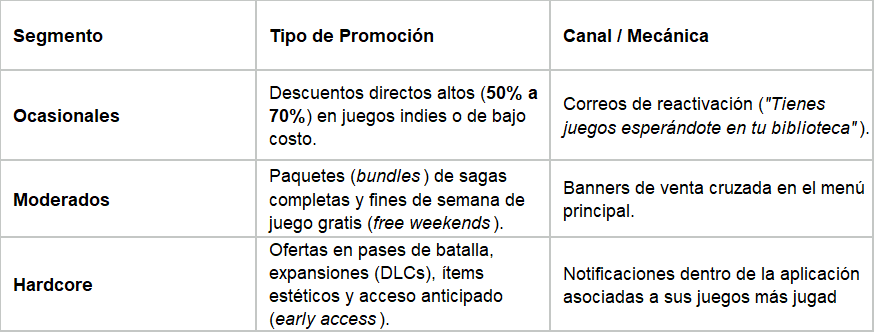

**3. Priorización para Campañas de Fidelización**

**Prioridad 1** — **Segmento Hardcore:**
Representan la base leal y sustentan la mayor retención y tiempo de sesión en la plataforma. Mantener satisfecho a este grupo tiene un valor de vida del cliente (Customer Lifetime Value - CLV) significativamente superior, ya que no solo consumen horas, sino que adquieren expansiones y arrastran a otros jugadores a la comunidad.

**Prioridad 2 — Segmento Moderado (con alto ratio de uso):**
Tienen un excelente potencial para convertirse en el próximo grupo hardcore si se les incentiva con programas de recompensas o puntos por horas jugadas.

4. Información Adicional para Mejorar la Segmentación
Para robustecer el modelo en fases futuras, sería de gran valor incorporar:

**Monto Monetario ($USD):** Conocer el gasto real en dinero por usuario para aplicar una segmentación RFM (Recencia, Frecuencia y Valor Monetario).

**Recencia de Conexión: **La fecha exacta de la última sesión para distinguir entre un usuario activo hoy y uno que ha abandonado la plataforma (churn).

**Género de Videojuegos: ** Etiquetas de categoría (RPG, estrategia, FPS, deportes) para segmentar por preferencias de contenido y no solo por volumen de horas.

**Interacción Social: **Datos sobre partidas multijugador, lista de amigos activa y participación en el mercado comunitario de Steam.